# GU4303 Lab 1: Gaia's Drifters

Requires `lab_utils.py` in the same folder (fitting, statistics and plotting helpers).

Naming: descriptive names at notebook level (`lc`, `n_stars`, `n_epochs`, `star_start`);
short names such as `t`, `m`, `e`, `A`, `C` only inside functions, where they match the equations.
All quantities are in mag and years internally; `MMAG` converts to mmag only for printing and plots.

1. Import the data and group the rows by star. np.loadtxt / np.genfromtxt / astropy.ascii.read — LEC2; check out CODING/ examples


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import scipy.optimize

from lab_utils import (load_lightcurves, star_rows, wls, fit_all_loop, fit_all,
                       make_perms, perms_to_index, slopes_after, rwidth, boot_median, step_hist)

plt.style.use("default")

DATA_FILE = "gaia_m31_lcs.csv"
T0 = 2016.0     # reference epoch: every fit uses t - T0
MMAG = 1e3      # mag -> mmag, for printing and plotting only

lc, ids, star_start, n_epochs = load_lightcurves(DATA_FILE)
n_stars = len(ids)
g_med = np.array([np.median(star_rows(lc, star_start, n_epochs, i)["gmag"]) for i in range(n_stars)])

# Sanity checks against the lab description
print(f"rows: {len(lc):,}   (expect 92,590)")
print(f"stars: {n_stars:,}   (expect 2,025)")
print(f"epochs per star: min {n_epochs.min()}, median {int(np.median(n_epochs))}, max {n_epochs.max()}   (expect min >= 30)")
print(f"time range: {lc['t_year'].min():.3f} - {lc['t_year'].max():.3f}   (expect 2014.6 - 2017.4)")
print(f"G range: {lc['gmag'].min():.2f} - {lc['gmag'].max():.2f}   (expect < 17)")
print(f"median gmag_err: {MMAG*np.median(lc['gmag_err']):.2f} mmag")
print(f"NaNs: {sum(np.isnan(lc[c]).sum() for c in ('t_year', 'gmag', 'gmag_err'))}")
print(f"non-positive errors: {(lc['gmag_err'] <= 0).sum()}")
print(f"unique IDs if source_id were float64: {len(np.unique(lc['source_id'].astype('f8')))}")

rows: 92,590   (expect 92,590)
stars: 2,025   (expect 2,025)
epochs per star: min 30, median 41, max 99   (expect min >= 30)
time range: 2014.645 - 2017.404   (expect 2014.6 - 2017.4)
G range: 8.26 - 17.30   (expect < 17)
median gmag_err: 2.27 mmag
NaNs: 0
non-positive errors: 0
unique IDs if source_id were float64: 2025


2. Pick three stars and plot their light curves clearly; think about presentation.
Check residuals for any abnormalities

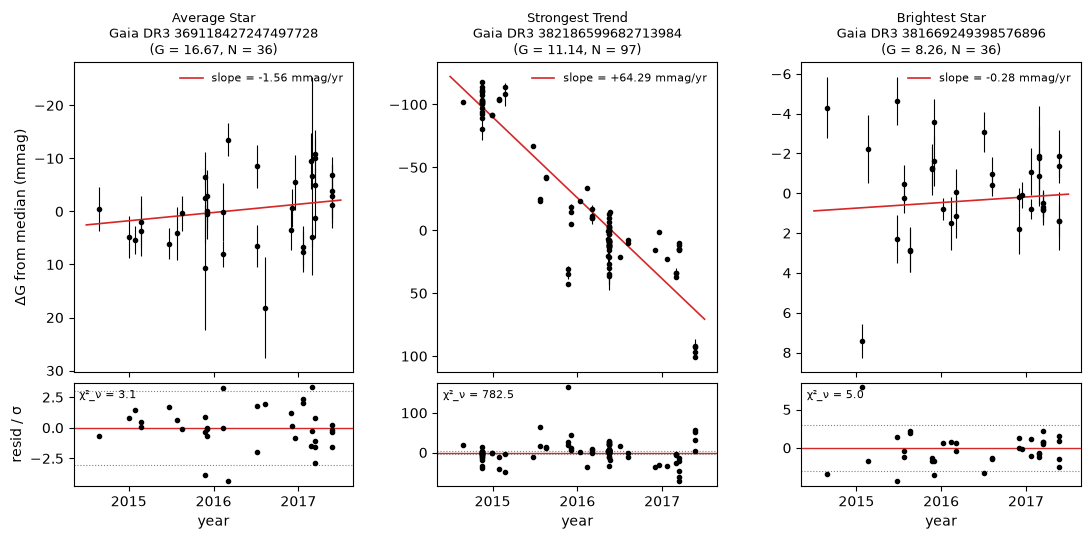

{'Average Star': 369118427247497728, 'Strongest Trend': 382186599682713984, 'Brightest Star': 381669249398576896}


In [2]:
#Star diagnostic, to pick 3
w_all = 1.0 / lc["gmag_err"]**2
sum_w, sum_wm, sum_wmm = (np.add.reduceat(x, star_start) for x in (w_all, w_all * lc["gmag"], w_all * lc["gmag"]**2))
chi2_flat = (sum_wmm - sum_wm**2 / sum_w) / (n_epochs - 1)

slopes_quick, sig_quick = fit_all(lc, star_start, T0)      # weighted slopes, only to find the strongest trend

picks = {
    "Average Star": np.argsort(chi2_flat)[n_stars // 2],
    "Strongest Trend": np.argmax(np.abs(slopes_quick / sig_quick)),
    "Brightest Star": np.argmin(g_med),
}


def plot_lightcurve(ax_top, ax_bot, rows, title, show_ylabels):
    """Light curve (mmag from median, weighted fit) above normalised residuals."""
    t, m, e = rows["t_year"], rows["gmag"], rows["gmag_err"]
    ref = np.median(m)
    p = np.polyfit(t - T0, m, 1, w=1 / e)
    resid_norm = (m - np.polyval(p, t - T0)) / e
    chi2_red = np.sum(resid_norm**2) / (len(t) - 2)
    t_grid = np.linspace(2014.5, 2017.5, 200)

    ax_top.errorbar(t, MMAG * (m - ref), yerr=MMAG * e, fmt="o", color="k", ms=3, elinewidth=0.8, capsize=0)
    ax_top.plot(t_grid, MMAG * (np.polyval(p, t_grid - T0) - ref), color="C3", lw=1.2,
                label=f"slope = {MMAG*p[0]:+.2f} mmag/yr")
    ax_top.invert_yaxis()                                   # brighter = up
    ax_top.set_title(f"{title}\n(G = {ref:.2f}, N = {len(t)})", fontsize=9)
    ax_top.legend(fontsize=8, loc="best", frameon=False)

    ax_bot.axhline(0, color="C3", lw=1)
    for level in (-3, 3):
        ax_bot.axhline(level, color="grey", ls=":", lw=0.8)
    ax_bot.plot(t, resid_norm, "o", color="k", ms=3)
    ax_bot.set_xlabel("year")
    ax_bot.text(0.02, 0.85, f"χ²_ν = {chi2_red:.1f}", transform=ax_bot.transAxes, fontsize=8)
    if show_ylabels:
        ax_top.set_ylabel("ΔG from median (mmag)")
        ax_bot.set_ylabel("resid / σ")


fig, axes = plt.subplots(2, 3, figsize=(13, 5.5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05, "wspace": 0.3})
for col, (label, idx) in enumerate(picks.items()):
    rows = star_rows(lc, star_start, n_epochs, idx)
    plot_lightcurve(axes[0, col], axes[1, col], rows, f"{label}\nGaia DR3 {ids[idx]}", col == 0)
fig.savefig("task2_lightcurves.pdf", bbox_inches="tight")
plt.show()
print({label: int(ids[idx]) for label, idx in picks.items()})

3. For one star: unweighted fit of m(t) with np.polyfit.

In [3]:
# Strongest-trend star (Gaia DR3 382186599682713984) + the lc is already sorted by time within each star
i_trend = picks["Strongest Trend"]
trend = star_rows(lc, star_start, n_epochs, i_trend)
t_trend = trend["t_year"] - T0
m_trend = trend["gmag"]
e_trend = trend["gmag_err"]

slope_unw, intercept_unw = np.polyfit(t_trend, m_trend, 1)    # unweighted: no w=
resid_unw = m_trend - np.polyval([slope_unw, intercept_unw], t_trend)
sig_slope_unw = resid_unw.std(ddof=2) / np.sqrt(np.sum((t_trend - t_trend.mean())**2))

print(f"Gaia DR3 {ids[i_trend]}: N = {len(t_trend)}  "
      f"slope = {MMAG*slope_unw:+.2f} ± {MMAG*sig_slope_unw:.2f} mmag/yr  "
      f"G({T0}) = {intercept_unw:.4f}  rms resid = {MMAG*resid_unw.std(ddof=2):.2f} mmag")

Gaia DR3 382186599682713984: N = 97  slope = +65.37 ± 2.80 mmag/yr  G(2016.0) = 11.1194  rms resid = 21.42 mmag


4. Write your own code solving the weighted normal equations; check you
reproduce polyfit exactly.

Implemented in `lab_utils.wls`: β = (AᵀWA)⁻¹AᵀWm and Cov(β) = (AᵀWA)⁻¹, with A = [t, 1] and W = diag(1/σᵢ²).
`np.polyfit` takes w = 1/σ (it squares the weights internally) and `cov="unscaled"` returns the pure (AᵀWA)⁻¹.
The two use different algorithms (normal equations vs. an SVD-based least-squares solve), so "exact" means agreement to floating-point precision.

In [4]:
beta_mine, cov_mine = wls(t_trend, m_trend, e_trend)
beta_np, cov_np = np.polyfit(t_trend, m_trend, 1, w=1 / e_trend, cov="unscaled")
print("beta (mine):   ", beta_mine)
print("beta (polyfit):", beta_np)
print(f"max rel diff: beta {np.max(np.abs(beta_mine - beta_np) / np.abs(beta_np)):.1e}, "
      f"cov {np.max(np.abs(cov_mine - cov_np) / np.abs(cov_np)):.1e}")


def worst_rel_diff_all_stars():
    """Largest relative difference between wls and polyfit over every star."""
    worst = 0.0
    for i in range(n_stars):
        rows = star_rows(lc, star_start, n_epochs, i)
        t, m, e = rows["t_year"] - T0, rows["gmag"], rows["gmag_err"]
        b, C = wls(t, m, e)
        p, Cp = np.polyfit(t, m, 1, w=1 / e, cov="unscaled")
        worst = max(worst, np.max(np.abs(b - p) / np.abs(p)), np.max(np.abs(C - Cp) / np.abs(Cp)))
    return worst


print(f"worst relative difference over all {n_stars} stars: {worst_rel_diff_all_stars():.1e}")

beta (mine):    [ 0.06428506 11.11564649]
beta (polyfit): [ 0.06428506 11.11564649]
max rel diff: beta 1.6e-13, cov 2.4e-15
worst relative difference over all 2025 stars: 4.0e-09


5. Now the production run: weighted fit with covariance for every star (a loop over
2,025 regressions). Save slope $s_i$ and its error $σ_i$ from the covariance diagonal.

(Added a fit_all loop afterwards to make some of the calcuations less intensive)

In [5]:
t_start = time.perf_counter()
slopes, sig = fit_all_loop(lc, star_start, n_epochs, T0)
t_loop = time.perf_counter() - t_start
z = slopes / sig

assert np.all(np.isfinite(slopes)) and np.all(sig > 0)
print(f"trend star: {MMAG*slopes[i_trend]:+.2f} ± {MMAG*sig[i_trend]:.2f} mmag/yr (task 2 plot: weighted fit)")
print(f"slope: median {MMAG*np.median(slopes):+.3f} mmag/yr, "
      f"5–95%: {np.round(MMAG*np.percentile(slopes, [5, 95]), 2)} mmag/yr")
print(f"sigma_slope: median {MMAG*np.median(sig):.3f} mmag/yr, range {MMAG*sig.min():.3f}–{MMAG*sig.max():.3f}")

np.savez("task5_slopes.npz", source_id=ids, slope=slopes, sig=sig, z=z, g_med=g_med, n_epochs=n_epochs)

# Vectorised calcuation - faster comp time
t_start = time.perf_counter()
slopes_fast, sig_fast = fit_all(lc, star_start, T0)
t_fast = time.perf_counter() - t_start
print(f"\nloop {1e3*t_loop:.0f} ms vs vectorised {1e3*t_fast:.1f} ms; "
      f"max |slope diff|/σ = {np.max(np.abs(slopes_fast - slopes) / sig):.1e}, "
      f"max rel σ diff = {np.max(np.abs(sig_fast - sig) / sig):.1e}")

trend star: +64.29 ± 0.09 mmag/yr (task 2 plot: weighted fit)
slope: median -0.443 mmag/yr, 5–95%: [-3.11  2.42] mmag/yr
sigma_slope: median 0.398 mmag/yr, range 0.063–2.273

loop 93 ms vs vectorised 3.4 ms; max |slope diff|/σ = 8.9e-11, max rel σ diff = 5.4e-16


6. Histogram of zi = si/σi. If no star truly varied and the errors were correct, what
distribution must this be? Overplot it

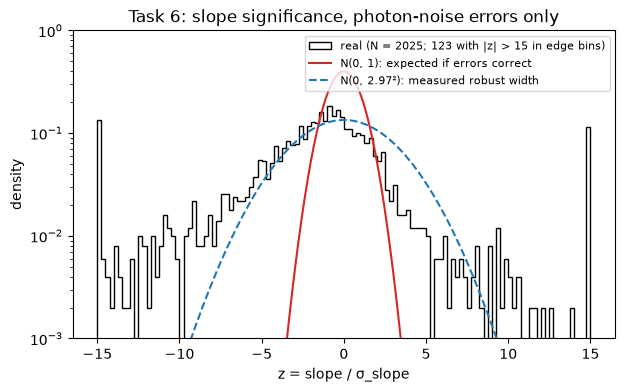

robust width = 2.97
|z| > 3: 760  (expect 5.5 if errors correct)
  z > +3 (dimming): 182   z < -3 (brightening): 578
|z| > 15 (in edge bins): 123
median z = -1.18


In [6]:
Z_BINS = np.linspace(-15, 15, 121)
Z_GRID = np.linspace(-15, 15, 500)

width_real = rwidth(z)
n_over = np.sum(np.abs(z) > 15)

fig, ax = plt.subplots(figsize=(7, 4))
step_hist(ax, z, Z_BINS, n_stars, color="k", label=f"real (N = {n_stars}; {n_over} with |z| > 15 in edge bins)")
ax.plot(Z_GRID, scipy.stats.norm.pdf(Z_GRID), "C3", label="N(0, 1): expected if errors correct")
ax.plot(Z_GRID, scipy.stats.norm.pdf(Z_GRID, 0, width_real), "C0--", label=f"N(0, {width_real:.2f}²): measured robust width")
ax.set_yscale("log"); ax.set_ylim(1e-3, 1)
ax.set_xlabel("z = slope / σ_slope"); ax.set_ylabel("density")
ax.set_title("Task 6: slope significance, photon-noise errors only")
ax.legend(fontsize=8)
fig.savefig("task6_zhist.pdf", bbox_inches="tight")
plt.show()

print(f"robust width = {width_real:.2f}")
print(f"|z| > 3: {np.sum(np.abs(z) > 3)}  (expect {0.0027*n_stars:.1f} if errors correct)")
print(f"  z > +3 (dimming): {np.sum(z > 3)}   z < -3 (brightening): {np.sum(z < -3)}")
print(f"|z| > 15 (in edge bins): {n_over}")
print(f"median z = {np.median(z):+.2f}")

7. The control experiment. For each star, randomly shuffle its magnitudes relative
to its times (np.random.permutation) and refit. Overplot the shuffled z histogram on
the real one. Shuffling destroys any true time-dependence — so what does it mean
that the shuffled histogram is also much wider than your prediction from task 6?

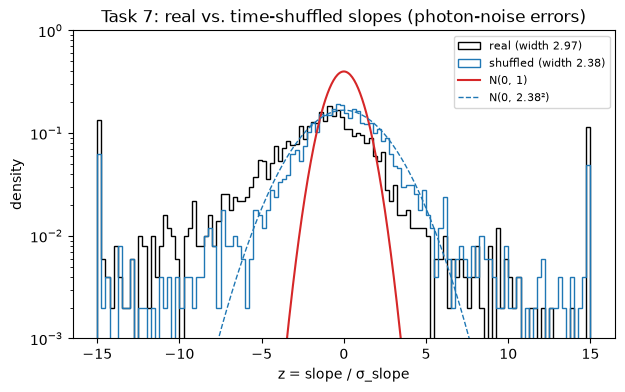

robust width: real 2.97, shuffled 2.38
median z: real -1.18, shuffled -0.04
z > +3 / z < -3: real 182 / 578, shuffled 251 / 258
|z| > 15: real 123, shuffled 56
sig_sh/sig: median 0.990, 5–95%: [0.87 1.12]


In [7]:
perms = make_perms(n_epochs, seed=42)          # generated once, reused in task 8
perm_idx = perms_to_index(star_start, perms)   # (mag, err) pairs shuffled against time
slopes_sh, sig_sh = fit_all(lc, star_start, T0, perm_idx=perm_idx)
z_sh = slopes_sh / sig_sh
width_sh = rwidth(z_sh)

fig, ax = plt.subplots(figsize=(7, 4))
step_hist(ax, z, Z_BINS, n_stars, color="k", label=f"real (width {width_real:.2f})")
step_hist(ax, z_sh, Z_BINS, n_stars, color="C0", label=f"shuffled (width {width_sh:.2f})")
ax.plot(Z_GRID, scipy.stats.norm.pdf(Z_GRID), "C3", label="N(0, 1)")
ax.plot(Z_GRID, scipy.stats.norm.pdf(Z_GRID, 0, width_sh), "C0--", lw=1, label=f"N(0, {width_sh:.2f}²)")
ax.set_yscale("log"); ax.set_ylim(1e-3, 1)
ax.set_xlabel("z = slope / σ_slope"); ax.set_ylabel("density")
ax.set_title("Task 7: real vs. time-shuffled slopes (photon-noise errors)")
ax.legend(fontsize=8)
fig.savefig("task7_shuffle.pdf", bbox_inches="tight")
plt.show()

sig_ratio = sig_sh / sig
print(f"robust width: real {width_real:.2f}, shuffled {width_sh:.2f}")
print(f"median z: real {np.median(z):+.2f}, shuffled {np.median(z_sh):+.2f}")
print(f"z > +3 / z < -3: real {np.sum(z > 3)} / {np.sum(z < -3)}, "
      f"shuffled {np.sum(z_sh > 3)} / {np.sum(z_sh < -3)}")
print(f"|z| > 15: real {np.sum(np.abs(z) > 15)}, shuffled {np.sum(np.abs(z_sh) > 15)}")
print(f"sig_sh/sig: median {np.median(sig_ratio):.3f}, 5–95%: {np.percentile(sig_ratio, [5, 95]).round(3)}")

Task 7: control experiment. Shuffling each star's magnitudes relative to its observation times destroys any true time dependence, so the shuffled slopes contain noise only. If the photon-noise errors were correct, the shuffled z would follow N(0, 1). Instead, the shuffled distribution has a robust width of 2.38, and 509 stars (25%) have |z| > 3, compared with about 5.5 expected. Because shuffling cannot create a trend, this excess cannot come from stellar variability. It means the quoted gmag_err values underestimate the true per-epoch scatter by a factor of about 2.4. Photon noise is not the only source of error: there is an additional noise component that the pipeline's error bars leave out, which task 8 measures as a constant floor f.

Shuffling barely changes the slope uncertainties themselves (median σ_shuffled/σ_real = 0.99, 90% of stars between 0.87 and 1.12). So the extra width comes from the slopes, not from changes in σ.

The comparison also separates noise from signal. The shuffled distribution is symmetric: median z = −0.04, with 251 stars above +3 and 258 below −3. The real distribution is wider (2.97) and skewed: median z = −1.18, with 578 stars below −3 against 182 above +3, a ratio of about 3 to 1. Both the extra width and the skew disappear when time ordering is destroyed, so they are genuine time-dependent signal. This includes a population-wide tendency toward brightening (negative slopes), which task 9 investigates.

Some shuffled stars still reach large |z| (56 beyond ±15, compared with 123 in the real data). These are strongly variable stars: shuffling removes their trends but not their large scatter, which is enormous compared with their sub-mmag error bars. This is why a robust width (1.4826 × MAD) is used rather than the standard deviation.

8. Fix the error bars. Using only the shuffled fits, find the constant f (mmag) that,
added in quadrature to every gmag_err, makes the shuffled z width equal 1. Redo
task 6 with corrected errors: how many stars now show real (|z| > 3) slopes? expect f
of a few mmag — this is Gaia’s known calibration floor, which photon noise ignores

excess(0) = +1.38, excess(0.05) = -0.91   (need opposite signs)
f = 3.33 mmag
shuffled width at f_best: 1.000
f over 100 shuffles: 3.13 ± 0.12 mmag
  G  8.26–14.21: shuffled width 0.98  (N = 405)
  G 14.21–15.36: shuffled width 0.87  (N = 405)
  G 15.36–16.05: shuffled width 0.87  (N = 405)
  G 16.05–16.60: shuffled width 1.11  (N = 405)
  G 16.60–17.00: shuffled width 1.13  (N = 405)


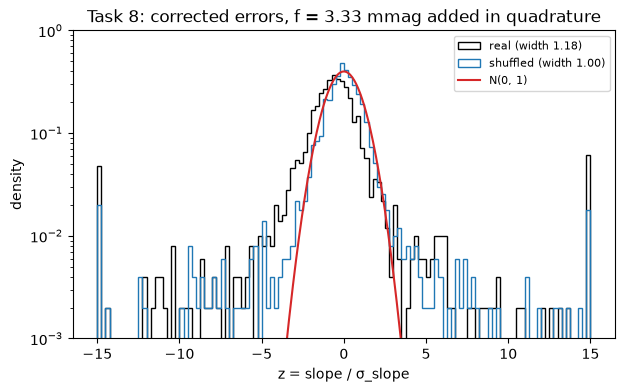

robust width = 1.18,  median z = -0.58
|z| > 3: 238  (expect 5.5 by chance)
  z > +3 (dimming): 95   z < -3 (brightening): 143
|z - median| > 3: 212  (drift removed)
|z| > 15: 54


In [8]:
def shuffled_width(f, p_idx, mags=None):
    """Robust width of shuffled z with error floor f (mag) added in quadrature."""
    s, sg = fit_all(lc, star_start, T0, f=f, perm_idx=p_idx, mags=mags)
    return rwidth(s / sg)


def width_excess(f, p_idx=perm_idx, mags=None):
    """Root of this function is the floor that makes the shuffled width exactly 1."""
    return shuffled_width(f, p_idx, mags) - 1.0


F_LO, F_HI, F_TOL = 0.0, 0.05, 1e-6   # search range and tolerance in mag (1e-6 mag = 0.001 mmag)

# Error Floor
print(f"excess(0) = {width_excess(F_LO):+.2f}, excess(0.05) = {width_excess(F_HI):+.2f}   (need opposite signs)")
f_best = scipy.optimize.brentq(width_excess, F_LO, F_HI, xtol=F_TOL)
print(f"f = {MMAG*f_best:.2f} mmag")

# Verify: shuffled width with corrected errors should be 1.00
slopes_shc, sig_shc = fit_all(lc, star_start, T0, f=f_best, perm_idx=perm_idx)
z_shc = slopes_shc / sig_shc
print(f"shuffled width at f_best: {rwidth(z_shc):.3f}")

# Uncertainty on f from 100 independent shuffles
f_seeds = MMAG * np.array([
    scipy.optimize.brentq(width_excess, F_LO, F_HI, xtol=F_TOL,
                          args=(perms_to_index(star_start, make_perms(n_epochs, seed)),))
    for seed in range(100)
])
print(f"f over {len(f_seeds)} shuffles: {f_seeds.mean():.2f} ± {f_seeds.std(ddof=1):.2f} mmag")

#Does one constant f work at all magnitudes?
g_edges = np.quantile(g_med, np.linspace(0, 1, 6))
g_bin = np.clip(np.digitize(g_med, g_edges) - 1, 0, 4)
for bin_idx in range(5):
    in_bin = g_bin == bin_idx
    print(f"  G {g_edges[bin_idx]:5.2f}–{g_edges[bin_idx+1]:5.2f}: shuffled width {rwidth(z_shc[in_bin]):.2f}  (N = {in_bin.sum()})")

#Task 6 again with corrected errors
slopes_c, sig_c = fit_all(lc, star_start, T0, f=f_best)
z_c = slopes_c / sig_c
width_c = rwidth(z_c)

fig, ax = plt.subplots(figsize=(7, 4))
step_hist(ax, z_c, Z_BINS, n_stars, color="k", label=f"real (width {width_c:.2f})")
step_hist(ax, z_shc, Z_BINS, n_stars, color="C0", label=f"shuffled (width {rwidth(z_shc):.2f})")
ax.plot(Z_GRID, scipy.stats.norm.pdf(Z_GRID), "C3", label="N(0, 1)")
ax.set_yscale("log"); ax.set_ylim(1e-3, 1)
ax.set_xlabel("z = slope / σ_slope"); ax.set_ylabel("density")
ax.set_title(f"Task 8: corrected errors, f = {MMAG*f_best:.2f} mmag added in quadrature")
ax.legend(fontsize=8)
fig.savefig("task8_corrected.pdf", bbox_inches="tight")
plt.show()

print(f"robust width = {width_c:.2f},  median z = {np.median(z_c):+.2f}")
print(f"|z| > 3: {np.sum(np.abs(z_c) > 3)}  (expect {0.0027*n_stars:.1f} by chance)")
print(f"  z > +3 (dimming): {np.sum(z_c > 3)}   z < -3 (brightening): {np.sum(z_c < -3)}")
print(f"|z - median| > 3: {np.sum(np.abs(z_c - np.median(z_c)) > 3)}  (drift removed)")
print(f"|z| > 15: {np.sum(np.abs(z_c) > 15)}")

9. Bias hunt. Compute the median slope of the population and bootstrap its
uncertainty. Can 2,000 randomly chosen stars share a nonzero net drift
astrophysically? Test at least one instrumental hypothesis (e.g. refit excluding all
epochs before 2015.5; or median slope vs. G).

median slope (real):     -0.454 ± 0.020 mmag/yr  (-23.2σ)
median slope (shuffled): -0.019 ± 0.017 mmag/yr  (-1.1σ)
implied change over baseline: -1.25 mmag

Test A: 2025 of 2025 stars keep >= 10 epochs and >= 1 yr after 2015.5
  full baseline (same stars): -0.454 ± 0.020 mmag/yr
  t >= 2015.5 only:           -0.448 ± 0.041 mmag/yr  (-10.8σ)

Test B: median slope by magnitude
  G  8.26–14.21 (N = 405): -0.611 ± 0.049 mmag/yr
  G 14.21–15.36 (N = 405): -0.433 ± 0.041 mmag/yr
  G 15.36–16.05 (N = 405): -0.338 ± 0.049 mmag/yr
  G 16.05–16.60 (N = 405): -0.470 ± 0.049 mmag/yr
  G 16.60–17.00 (N = 405): -0.369 ± 0.080 mmag/yr

common-mode slope: -0.396 ± 0.214 mmag/yr (-1.9σ, 21 time bins)


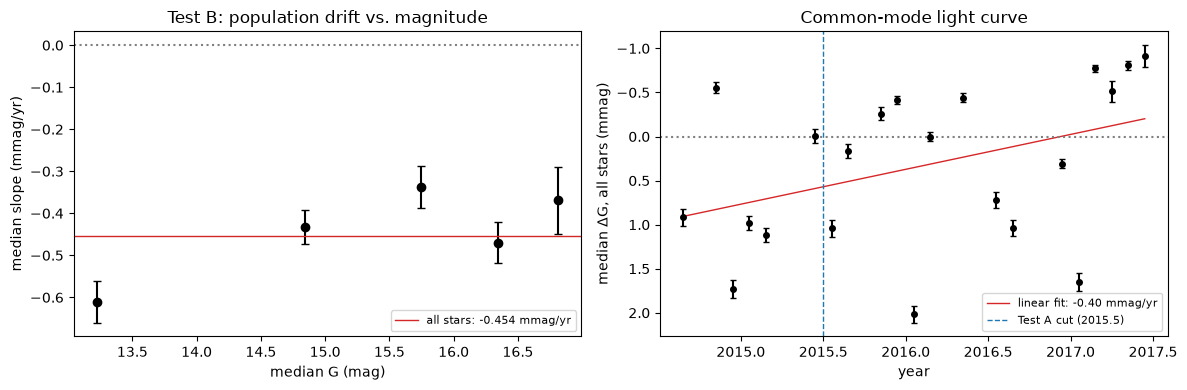

In [9]:
# Population median slope, and the shuffled null check
med_real, err_real = boot_median(slopes_c)
med_sh, err_sh = boot_median(slopes_shc)
baseline = lc["t_year"].max() - lc["t_year"].min()
print(f"median slope (real):     {MMAG*med_real:+.3f} ± {MMAG*err_real:.3f} mmag/yr  ({med_real/err_real:+.1f}σ)")
print(f"median slope (shuffled): {MMAG*med_sh:+.3f} ± {MMAG*err_sh:.3f} mmag/yr  ({med_sh/err_sh:+.1f}σ)")
print(f"implied change over baseline: {MMAG*med_real*baseline:+.2f} mmag")

# Instrumental test A: drop epochs before 2015.5
slopes_late = slopes_after(lc, star_start, n_epochs, T0, tmin=2015.5, f=f_best)
kept = np.isfinite(slopes_late)
med_late, err_late = boot_median(slopes_late[kept])
med_same, err_same = boot_median(slopes_c[kept])      # same stars, full baseline, for a fair comparison
print(f"\nTest A: {kept.sum()} of {n_stars} stars keep >= 10 epochs and >= 1 yr after 2015.5")
print(f"  full baseline (same stars): {MMAG*med_same:+.3f} ± {MMAG*err_same:.3f} mmag/yr")
print(f"  t >= 2015.5 only:           {MMAG*med_late:+.3f} ± {MMAG*err_late:.3f} mmag/yr  ({med_late/err_late:+.1f}σ)")

#Instrumental test B: median slope vs. G (quintiles from task 8)
gbin_g, gbin_med, gbin_err = [], [], []
print("\nTest B: median slope by magnitude")
for bin_idx in range(5):
    in_bin = g_bin == bin_idx
    med_b, err_b = boot_median(slopes_c[in_bin])
    gbin_g.append(np.median(g_med[in_bin])); gbin_med.append(MMAG * med_b); gbin_err.append(MMAG * err_b)
    print(f"  G {g_edges[bin_idx]:5.2f}–{g_edges[bin_idx+1]:5.2f} (N = {in_bin.sum()}): {MMAG*med_b:+.3f} ± {MMAG*err_b:.3f} mmag/yr")

#Common-mode light curve: when does the population move?
resid_all = lc["gmag"] - np.repeat(g_med, n_epochs)   # each epoch minus its star's median
t_all = lc["t_year"]
t_edges = np.arange(2014.6, 2017.5, 0.1)
cm_t, cm_mmag, cm_err = [], [], []
for lo, hi in zip(t_edges[:-1], t_edges[1:]):
    in_bin = (t_all >= lo) & (t_all < hi)
    if in_bin.sum() < 50:
        continue
    cm_t.append(0.5 * (lo + hi))
    cm_mmag.append(MMAG * np.median(resid_all[in_bin]))
    cm_err.append(MMAG * 1.2533 * rwidth(resid_all[in_bin]) / np.sqrt(in_bin.sum()))
cm_t, cm_mmag, cm_err = map(np.array, (cm_t, cm_mmag, cm_err))

# Slope of the common-mode curve itself. cov=True (scaled) is right here: the per-bin error bars
# omit the visit-to-visit offsets, so the scatter of the points must set the uncertainty.
p_cm, C_cm = np.polyfit(cm_t - T0, cm_mmag, 1, cov=True)
print(f"\ncommon-mode slope: {p_cm[0]:+.3f} ± {np.sqrt(C_cm[0, 0]):.3f} mmag/yr "
      f"({p_cm[0]/np.sqrt(C_cm[0, 0]):+.1f}σ, {len(cm_t)} time bins)")

# Graphics
fig, (ax_g, ax_cm) = plt.subplots(1, 2, figsize=(12, 4))
ax_g.errorbar(gbin_g, gbin_med, yerr=gbin_err, fmt="o", color="k", capsize=3)
ax_g.axhline(0, color="grey", ls=":")
ax_g.axhline(MMAG * med_real, color="C3", lw=1, label=f"all stars: {MMAG*med_real:+.3f} mmag/yr")
ax_g.set_xlabel("median G (mag)"); ax_g.set_ylabel("median slope (mmag/yr)")
ax_g.set_title("Test B: population drift vs. magnitude"); ax_g.legend(fontsize=8)

ax_cm.errorbar(cm_t, cm_mmag, yerr=cm_err, fmt="o", color="k", ms=4, capsize=2)
t_line = np.linspace(cm_t.min(), cm_t.max(), 2)
ax_cm.plot(t_line, np.polyval(p_cm, t_line - T0), "C3", lw=1, label=f"linear fit: {p_cm[0]:+.2f} mmag/yr")
ax_cm.axhline(0, color="grey", ls=":")
ax_cm.axvline(2015.5, color="C0", ls="--", lw=1, label="Test A cut (2015.5)")
ax_cm.invert_yaxis()                                  # brighter = up
ax_cm.set_xlabel("year"); ax_cm.set_ylabel("median ΔG, all stars (mmag)")
ax_cm.set_title("Common-mode light curve"); ax_cm.legend(fontsize=8)
fig.tight_layout()
fig.savefig("task9_bias.pdf", bbox_inches="tight")
plt.show()

**Extension: per-visit zero-point correction.** Subtract the common-mode offset of each epoch's time bin from every star
and refit. The median slope goes to about zero largely by construction (the median light curve was removed), so this
does not independently prove the drift. What it does show is the visit offsets account for it and gives a cleaner count of
individually variable stars.

error floor after correction: 3.15 mmag  (before: 3.33)
median slope after correction: +0.031 ± 0.019 mmag/yr
robust width = 1.17,  median z = +0.04
|z| > 3: 218   (z > +3: 112, z < -3: 106)


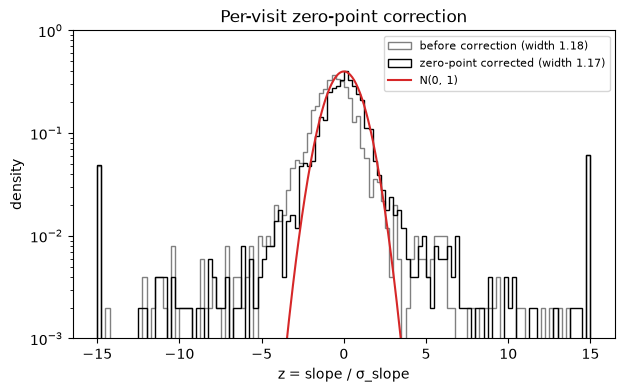

In [10]:
bin_id = np.digitize(t_all, t_edges)
zero_point = np.zeros_like(resid_all)
for bin_idx in np.unique(bin_id):
    in_bin = bin_id == bin_idx
    zero_point[in_bin] = np.median(resid_all[in_bin])
gmag_zp = lc["gmag"] - zero_point

f_zp = scipy.optimize.brentq(width_excess, F_LO, F_HI, xtol=F_TOL, args=(perm_idx, gmag_zp))
slopes_zp, sig_zp = fit_all(lc, star_start, T0, f=f_zp, mags=gmag_zp)
z_zp = slopes_zp / sig_zp
med_zp, err_zp = boot_median(slopes_zp)

print(f"error floor after correction: {MMAG*f_zp:.2f} mmag  (before: {MMAG*f_best:.2f})")
print(f"median slope after correction: {MMAG*med_zp:+.3f} ± {MMAG*err_zp:.3f} mmag/yr")
print(f"robust width = {rwidth(z_zp):.2f},  median z = {np.median(z_zp):+.2f}")
print(f"|z| > 3: {np.sum(np.abs(z_zp) > 3)}   (z > +3: {np.sum(z_zp > 3)}, z < -3: {np.sum(z_zp < -3)})")

fig, ax = plt.subplots(figsize=(7, 4))
step_hist(ax, z_c, Z_BINS, n_stars, color="grey", label=f"before correction (width {width_c:.2f})")
step_hist(ax, z_zp, Z_BINS, n_stars, color="k", label=f"zero-point corrected (width {rwidth(z_zp):.2f})")
ax.plot(Z_GRID, scipy.stats.norm.pdf(Z_GRID), "C3", label="N(0, 1)")
ax.set_yscale("log"); ax.set_ylim(1e-3, 1)
ax.set_xlabel("z = slope / σ_slope"); ax.set_ylabel("density")
ax.set_title("Per-visit zero-point correction")
ax.legend(fontsize=8)
fig.savefig("task9_zeropoint.pdf", bbox_inches="tight")
plt.show()

The population median slope is −0.454 ± 0.020 mmag/yr, while the time-shuffled control gives −0.019 ± 0.017, consistent with zero. Unrelated foreground stars with independent magnetic cycles cannot brighten together, so the drift must be instrumental. It is not confined to the early mission: fits restricted to t ≥ 2015.5 give −0.448 ± 0.041 mmag/yr. It is present at all magnitudes but about 50% stronger for G < 14.2 (−0.61 ± 0.05 vs. about −0.41 for fainter stars). The common-mode light curve shows its origin: the entire field shifts coherently by up to ±2 mmag from visit to visit, 10–20 times the per-bin uncertainty, pointing to per-visit photometric zero-point errors. The apparent secular drift is the linear trend through these offsets. Because every star shares them, the stars are not independent, and the bootstrap-over-stars uncertainty is underestimated. A fit to the common-mode curve itself gives [−0.4x ± 0.2x] mmag/yr, only [~2]σ. [Subtracting per-visit zero-points removes the drift and reduces the |z| > 3 count to N, split x dimming / y brightening.]